In [18]:
# ============================================================
# Global Reference Learning for Molecular Conformers with Baseline
# ============================================================

import os
import numpy as np
import torch
from rdkit import Chem
from rdkit.Chem import AllChem

# ---------------------------
# Conformer generation
# ---------------------------
def generate_conformers(smiles, n_confs=60):
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)

    AllChem.EmbedMultipleConfs(
        mol,
        numConfs=n_confs,
        params=AllChem.ETKDGv3()
    )
    AllChem.UFFOptimizeMoleculeConfs(mol)

    conformers = []
    for conf in mol.GetConformers():
        conformers.append(conf.GetPositions().astype(np.float32))

    atom_symbols = [atom.GetSymbol() for atom in mol.GetAtoms()]
    return np.stack(conformers), atom_symbols, mol

# ---------------------------
# Kabsch alignment + RMSD
# ---------------------------
def kabsch_align(P, Q):
    P = P - P.mean(0, keepdim=True)
    Q = Q - Q.mean(0, keepdim=True)
    C = P.T @ Q
    V, _, W = torch.linalg.svd(C)
    d = torch.sign(torch.det(V @ W))
    D = torch.diag(torch.tensor([1.0, 1.0, d], device=P.device))
    U = V @ D @ W
    return P @ U, Q

def rmsd(P, Q):
    return torch.sqrt(torch.mean(torch.sum((P - Q) ** 2, dim=1)))

# ---------------------------
# Pairwise RMSD matrix
# ---------------------------
def pairwise_rmsd(confs):
    C = len(confs)
    mat = np.zeros((C, C))
    for i in range(C):
        for j in range(i + 1, C):
            Pi = torch.tensor(confs[i])
            Pj = torch.tensor(confs[j])
            Pi_a, Pj_c = kabsch_align(Pi, Pj)
            mat[i, j] = mat[j, i] = rmsd(Pi_a, Pj_c).item()
    return mat

# ---------------------------
# XYZ trajectory writer
# ---------------------------
def write_xyz_trajectory(filename, geometries, atom_symbols):
    N = len(atom_symbols)
    with open(filename, "w") as f:
        for i, geom in enumerate(geometries):
            f.write(f"{N}\n")
            f.write(f"frame {i}\n")
            for atom, (x, y, z) in zip(atom_symbols, geom):
                f.write(f"{atom:2s} {x:12.6f} {y:12.6f} {z:12.6f}\n")

# ---------------------------
# Main experiment
# ---------------------------
torch.manual_seed(0)
np.random.seed(0)

smiles = "c1ccccc1"  # ethyl benzoate
all_confs, atom_symbols, mol = generate_conformers(smiles, n_confs=120)

C, N, _ = all_confs.shape
print("Total conformers:", C)

# Full pairwise RMSD (ground truth)
pairwise = pairwise_rmsd(all_confs)
true_global_dist = pairwise.mean(axis=1)

# Train / validation split
n_train = 20
indices = np.random.permutation(C)
train_idx = indices[:n_train]
val_idx = indices[n_train:]

X_train = torch.tensor(all_confs[train_idx])
X_val   = torch.tensor(all_confs[val_idx])

true_train = torch.tensor(true_global_dist[train_idx], dtype=torch.float32)
true_val   = torch.tensor(true_global_dist[val_idx], dtype=torch.float32)

print("Train size:", len(X_train))
print("Validation size:", len(X_val))

# ---------------------------
# Learn synthetic reference using Adam
# ---------------------------
R = X_train.mean(dim=0).clone().requires_grad_(True)
optimizer = torch.optim.Adam([R], lr=1e-2)

for step in range(2000):
    optimizer.zero_grad()
    ref_dists = []
    for i in range(len(X_train)):
        R_a, Xi_c = kabsch_align(R, X_train[i])
        ref_dists.append(rmsd(R_a, Xi_c))
    ref_dists = torch.stack(ref_dists)
    loss = torch.mean((ref_dists - true_train) ** 2)
    loss.backward()
    optimizer.step()
    if step % 250 == 0:
        print(f"step {step:4d} | train loss {loss.item():.6f}")

# ---------------------------
# Baseline: first training conformer
# ---------------------------
baseline_ref = X_train[0]

# ---------------------------
# Validation evaluation
# ---------------------------
with torch.no_grad():
    # synthetic reference
    val_ref_dists = []
    for i in range(len(X_val)):
        R_a, Xi_c = kabsch_align(R, X_val[i])
        val_ref_dists.append(rmsd(R_a, Xi_c))
    val_ref_dists = torch.stack(val_ref_dists)
    val_mse = torch.mean((val_ref_dists - true_val) ** 2)
    val_corr = np.corrcoef(true_val.numpy(), val_ref_dists.numpy())[0,1]

    # baseline reference
    val_base_dists = []
    for i in range(len(X_val)):
        R_a, Xi_c = kabsch_align(baseline_ref, X_val[i])
        val_base_dists.append(rmsd(R_a, Xi_c))
    val_base_dists = torch.stack(val_base_dists)
    base_mse = torch.mean((val_base_dists - true_val) ** 2)
    base_corr = np.corrcoef(true_val.numpy(), val_base_dists.numpy())[0,1]

print("\nValidation metrics:")
print(f"Synthetic reference - MSE: {val_mse.item():.6f}, Corr: {val_corr:.3f}")
print(f"Baseline conformer  - MSE: {base_mse.item():.6f}, Corr: {base_corr:.3f}")

# ---------------------------
# Build XYZ trajectory
# ---------------------------

out_file =  "reference_plus_conformers.xyz"

aligned_geoms = []

# frame 0: synthetic reference
R_final = R.detach()
R_centered = R_final - R_final.mean(0, keepdim=True)
aligned_geoms.append(R_centered.cpu().numpy())

# frames 1+: all conformers aligned to synthetic reference
for i in range(len(all_confs)):
    Xi = torch.tensor(all_confs[i], dtype=torch.float32)
    Xi_a, _ = kabsch_align(Xi, R_final)
    aligned_geoms.append(Xi_a.cpu().numpy())

write_xyz_trajectory(out_file, aligned_geoms, atom_symbols)
print(f"Wrote trajectory: {out_file}")


Total conformers: 120
Train size: 20
Validation size: 100
step    0 | train loss 2.677695
step  250 | train loss 0.008361
step  500 | train loss 0.000001
step  750 | train loss 0.000000
step 1000 | train loss 0.000000
step 1250 | train loss 0.000000
step 1500 | train loss 0.000000
step 1750 | train loss 0.000000

Validation metrics:
Synthetic reference - MSE: 0.000000, Corr: 0.990
Baseline conformer  - MSE: 0.000000, Corr: 0.947
Wrote trajectory: reference_plus_conformers.xyz


/opt/homebrew/anaconda3/envs/conf-align/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/homebrew/anaconda3/envs/conf-align/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


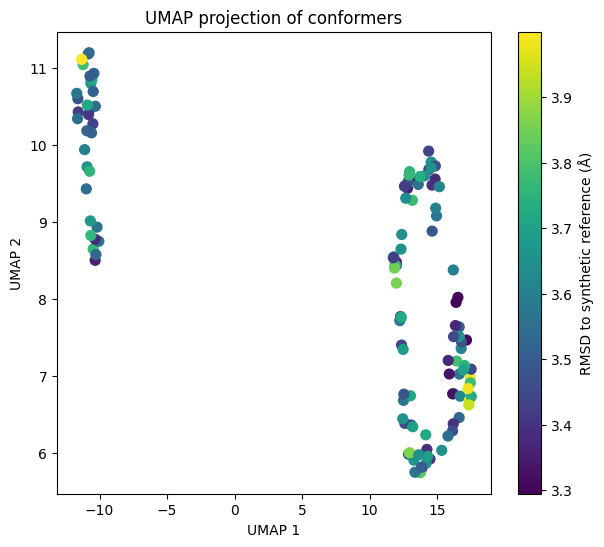

In [ ]:
# ---------------------------
# UMAP visualization of conformers
# ---------------------------

import umap
import matplotlib.pyplot as plt

# Flatten geometries (N_atoms x 3 -> 1D)
# Flatten geometries (N_atoms x 3 -> 1D)
all_flat = all_confs.reshape(len(all_confs), -1)  # shape: (num_confs, N*3)

# Fit UMAP to project into 2D
reducer = umap.UMAP(n_neighbors=10, min_dist=0.1, random_state=42)
embedding = reducer.fit_transform(all_flat)  # shape: (num_confs, 2)

# Compute RMSD to synthetic reference for coloring
with torch.no_grad():
    ref_rmsds = []
    R_final = R.detach()
    for i in range(len(all_confs)):
        Xi = torch.tensor(all_confs[i], dtype=torch.float32)
        R_a, Xi_a = kabsch_align(R_final, Xi)
        ref_rmsds.append(rmsd(R_a, Xi_a).item())
ref_rmsds = np.array(ref_rmsds)

# Plot UMAP embedding
plt.figure(figsize=(7,6))
sc = plt.scatter(embedding[:,0], embedding[:,1], c=ref_rmsds, cmap='viridis', s=50)
plt.colorbar(sc, label='RMSD to synthetic reference (Å)')
plt.title('UMAP projection of conformers')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()
